# Model A: Similarity Engine (Lookalike Identification)

This notebook finds lookalike players using style-based similarity.

Main methods:
- PCA for style components
- KNN with cosine similarity for nearest players
- K-means for archetype labels

Main outputs:
- Top-K similar players
- Similarity score
- Archetype number and archetype name
- PCA projection columns (all `pc` columns used by each table model)

In [115]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

## Step 1: Load Prepared Data

In this step, we load the 4 ready-to-model CSV files (GK, DF, MF, FW).
These files already have z-scored features from the data processing notebook.

Logic:
- keep one table per position group to avoid cross-position comparisons
- store them in a dictionary so later loops can train the same pipeline for each table

In [ ]:
META_COLS = [
    'player', 'season_end_year', 'squad', 'comp',
    'nation', 'position_group_model', 'age', 'league_strength'
 ]

def find_model_ready_dir():
    # Try a few common relative paths first, then fallback to absolute path.
    candidate_paths = [
        Path.cwd() / 'data' / 'model_ready',
        Path.cwd().parent / 'data' / 'model_ready',
        Path.cwd().parent.parent / 'data' / 'model_ready',
        Path(r'C:\Users\User\Desktop\projects\Portfolio\Pet-projects\moneyball-like\data\model_ready'),
    ]

    for path in candidate_paths:
        if (path / 'model_ready_gk_z.csv').exists():
            return path

    raise FileNotFoundError('Could not find model_ready folder with the four CSV files.')

MODEL_READY_DIR = find_model_ready_dir()
print('Using model-ready data from:', MODEL_READY_DIR)

table_files = {
    'GK': MODEL_READY_DIR / 'model_ready_gk_z.csv',
    'DF': MODEL_READY_DIR / 'model_ready_df_z.csv',
    'MF': MODEL_READY_DIR / 'model_ready_mf_z.csv',
    'FW': MODEL_READY_DIR / 'model_ready_fw_z.csv',
}

tables = {}
for table_name, file_path in table_files.items():
    tables[table_name] = pd.read_csv(file_path)
    print(f"{table_name}: {tables[table_name].shape}")

Using model-ready data from: c:\Users\User\Desktop\projects\moneyball like\data\model_ready
GK: (2282, 61)
DF: (6294, 90)
MF: (8573, 103)
FW: (2600, 97)


## Step 2: Train Similarity Models

For each position table, we:
- run PCA to build style components
- build KNN with cosine distance
- run K-means to assign archetype labels

Model choices in this notebook:
- PCA components: set per table in `PCA_COMPONENTS_BY_TABLE`
- KNN top lookalikes (`k`): chosen from elbow plot per position group
- archetype counts: selected with silhouette plus practical football constraints

Why these settings:
- position groups have different feature complexity, so PCA count is set per table.
- elbow-based `k` avoids choosing neighbors only by guess.
- silhouette gives a clean statistical signal for archetype count, then football logic is used for final tuning (especially MF).

Code logic in this section:
- select numeric feature columns only (metadata is excluded)
- fit PCA and keep component scores (`pc1`, `pc2`, ... )
- fit KNN on PCA scores for similarity search
- fit KMeans on the same PCA scores for archetype labels

In [117]:
PCA_COMPONENTS_BY_TABLE = {
    'GK': 10,
    'DF': 10,
    'MF': 12,
    'FW': 11,
}

# Initial archetype counts; later we validate and update these from quality plots.
N_ARCHETYPES_BY_TABLE = {
    'GK': 5,
    'DF': 6,
    'MF': 8,
    'FW': 5,
}

def fit_one_position_model(df, table_name, pca_components=8, n_clusters=5):
    data = df.copy()

    # Use numeric columns that are not metadata.
    feature_cols = []
    for col in data.columns:
        if col not in META_COLS and pd.api.types.is_numeric_dtype(data[col]):
            feature_cols.append(col)

    if len(feature_cols) == 0:
        raise ValueError(f"{table_name}: no numeric feature columns found.")

    X = data[feature_cols].to_numpy()

    pca = PCA(n_components=pca_components, random_state=42)
    pca_scores = pca.fit_transform(X)

    pc_columns = []
    for i in range(pca_scores.shape[1]):
        pc_columns.append(f'pc{i + 1}')
    pca_df = pd.DataFrame(pca_scores, columns=pc_columns, index=data.index)

    knn = NearestNeighbors(metric='cosine', algorithm='brute')
    knn.fit(pca_scores)

    n_clusters = N_ARCHETYPES_BY_TABLE.get(table_name, n_clusters)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(pca_scores)

    data['archetype'] = cluster_labels
    data = pd.concat([data, pca_df], axis=1)

    model = {
        'table_name': table_name,
        'data': data,
        'feature_cols': feature_cols,
        'pca': pca,
        'pca_scores': pca_scores,
        'knn': knn,
        'kmeans': kmeans,
    }
    return model

models = {}
for table_name, df_table in tables.items():
    pca_components = PCA_COMPONENTS_BY_TABLE.get(table_name, 8)
    n_clusters = N_ARCHETYPES_BY_TABLE.get(table_name, 5)
    models[table_name] = fit_one_position_model(
        df=df_table,
        table_name=table_name,
        pca_components=pca_components,
        n_clusters=n_clusters
    )

for table_name, model in models.items():
    explained = model['pca'].explained_variance_ratio_.sum()
    k_used = N_ARCHETYPES_BY_TABLE.get(table_name, 5)
    print(
        f"{table_name}: players={len(model['data'])}, "
        f"features={len(model['feature_cols'])}, "
        f"pcs={model['pca_scores'].shape[1]}, "
        f"explained_var={explained:.3f}, "
        f"archetypes={k_used}"
    )

GK: players=2282, features=53, pcs=10, explained_var=0.774, archetypes=5
DF: players=6294, features=82, pcs=10, explained_var=0.563, archetypes=6
MF: players=8573, features=95, pcs=12, explained_var=0.541, archetypes=8
FW: players=2600, features=89, pcs=11, explained_var=0.514, archetypes=5


## Step 2.1: Scree Plot

This plot shows explained variance by PCA component for each position group.
We use it to see how much structure is captured by the first components.

Decision logic:
- use scree shape and cumulative variance to pick practical component counts per table.
- chosen component counts are marked with vertical lines on each plot.
- current settings come from `PCA_COMPONENTS_BY_TABLE` in the training cell.

How to read the plot:
- the first curve shows variance by each single component
- the cumulative curve shows total variance captured up to that component
- after the curve flattens, adding more components usually gives smaller gains

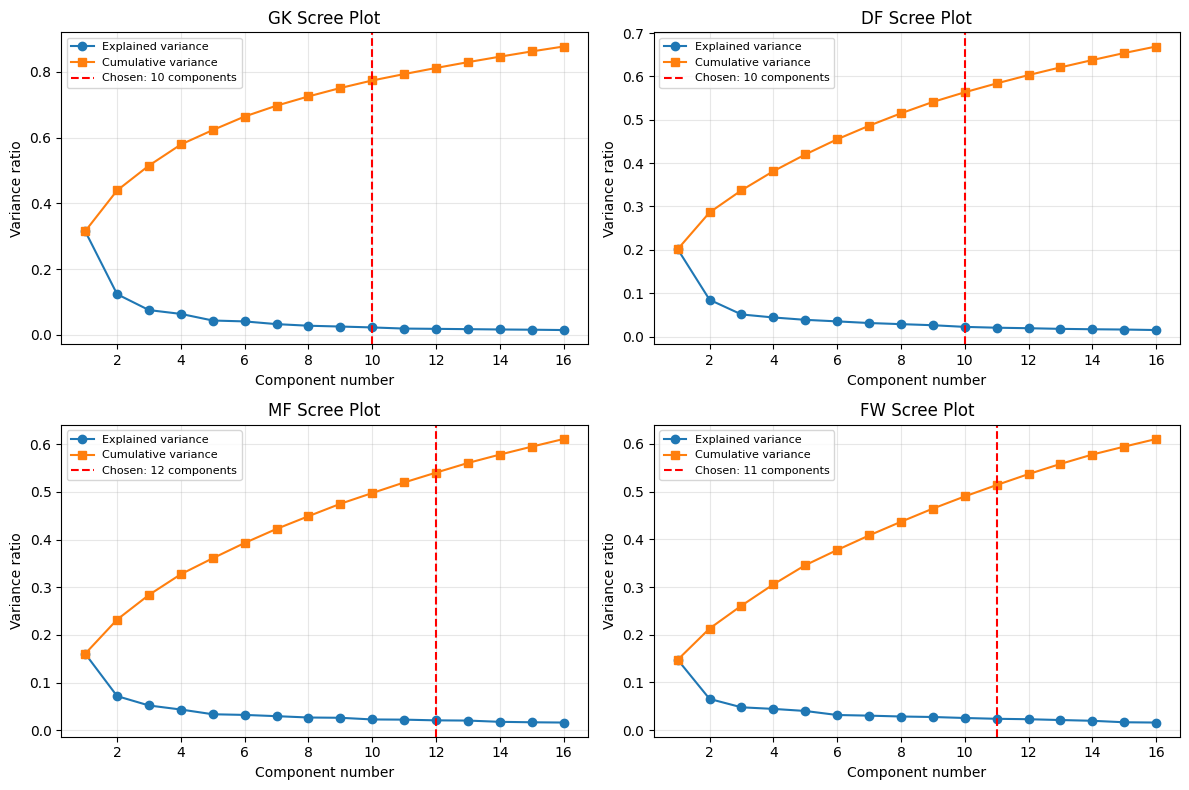

Chosen PCA components by table: {'GK': 10, 'DF': 10, 'MF': 12, 'FW': 11}


In [118]:
# Scree plots for all position groups
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, (table_name, df_table) in enumerate(tables.items()):
    feature_cols = []
    for col in df_table.columns:
        if col not in META_COLS and pd.api.types.is_numeric_dtype(df_table[col]):
            feature_cols.append(col)

    X = df_table[feature_cols].to_numpy()
    pca_full = PCA(random_state=42)
    pca_full.fit(X)

    explained = pca_full.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    chosen_components = PCA_COMPONENTS_BY_TABLE.get(table_name, 8)
    x = np.arange(1, min(16, len(explained)) + 1)
    axes[i].plot(x, explained[:len(x)], marker='o', label='Explained variance')
    axes[i].plot(x, cumulative[:len(x)], marker='s', label='Cumulative variance')
    axes[i].axvline(chosen_components, color='red', linestyle='--', label=f'Chosen: {chosen_components} components')
    axes[i].set_title(f'{table_name} Scree Plot')
    axes[i].set_xlabel('Component number')
    axes[i].set_ylabel('Variance ratio')
    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Chosen PCA components by table:', PCA_COMPONENTS_BY_TABLE)

## Step 2.2: Elbow Method for KNN `k`

This plot helps choose how many neighbors to return in lookalike search.
For each table, we plot average distance to the k-th nearest neighbor.

Decision logic:
- pick the elbow point where distance starts increasing faster
- use that value as recommended `k` for top lookalikes in that table

How the code works:
- for each `k`, it computes neighbor distances in PCA space
- it keeps the average distance to the k-th neighbor
- it applies a simple geometric elbow rule to find a stable `k`

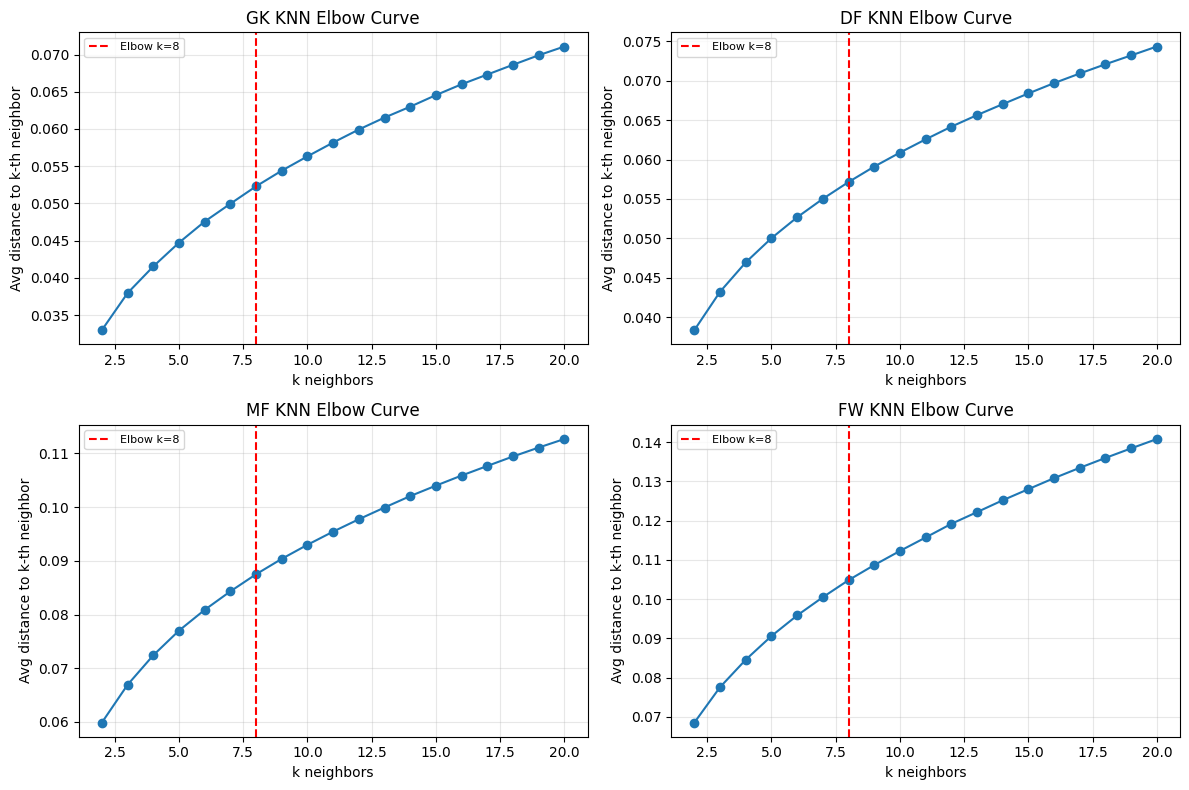

Recommended k by table: {'GK': 8, 'DF': 8, 'MF': 8, 'FW': 8}


In [119]:
# Elbow curves and recommended k for each table
def pick_elbow_k(k_values, y_values):
    """
    Simple elbow rule: choose point with max distance from line between endpoints.
    """
    x = np.array(k_values, dtype=float)
    y = np.array(y_values, dtype=float)

    x1, y1 = x[0], y[0]
    x2, y2 = x[-1], y[-1]

    numerator = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    denominator = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    distances = numerator / (denominator + 1e-12)

    elbow_idx = int(np.argmax(distances))
    return int(k_values[elbow_idx])


recommended_k_by_table = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, (table_name, model) in enumerate(models.items()):
    pca_scores = model['pca_scores']

    k_values = list(range(2, 21))
    avg_k_distances = []

    for k in k_values:
        nn = NearestNeighbors(metric='cosine', algorithm='brute')
        nn.fit(pca_scores)
        distances, _ = nn.kneighbors(pca_scores, n_neighbors=k + 1)
        # Use distance to k-th neighbor (index k, because index 0 is self).
        avg_dist = distances[:, k].mean()
        avg_k_distances.append(avg_dist)

    best_k = pick_elbow_k(k_values, avg_k_distances)
    recommended_k_by_table[table_name] = best_k

    axes[i].plot(k_values, avg_k_distances, marker='o')
    axes[i].axvline(best_k, color='red', linestyle='--', label=f'Elbow k={best_k}')
    axes[i].set_title(f'{table_name} KNN Elbow Curve')
    axes[i].set_xlabel('k neighbors')
    axes[i].set_ylabel('Avg distance to k-th neighbor')
    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Recommended k by table:', recommended_k_by_table)

## Step 2.3: Archetype Count Selection (KMeans)

To set archetype count, we evaluate KMeans for each table over a range of cluster values.

Metric used:
- Silhouette (higher is better)

Final rule used:
- GK = 5
- DF = 6
- FW = 5
- MF = 8

Note for MF:
- statistically, a lower value (around 4) can be better by silhouette,
- but based on football knowledge, MF roles are more diverse, so we use 8.

Code logic in this section:
- test several `k` values for each position table
- calculate silhouette for each tested `k`
- compare statistical best `k` with practical final `k`
- update model archetype labels using final selected values

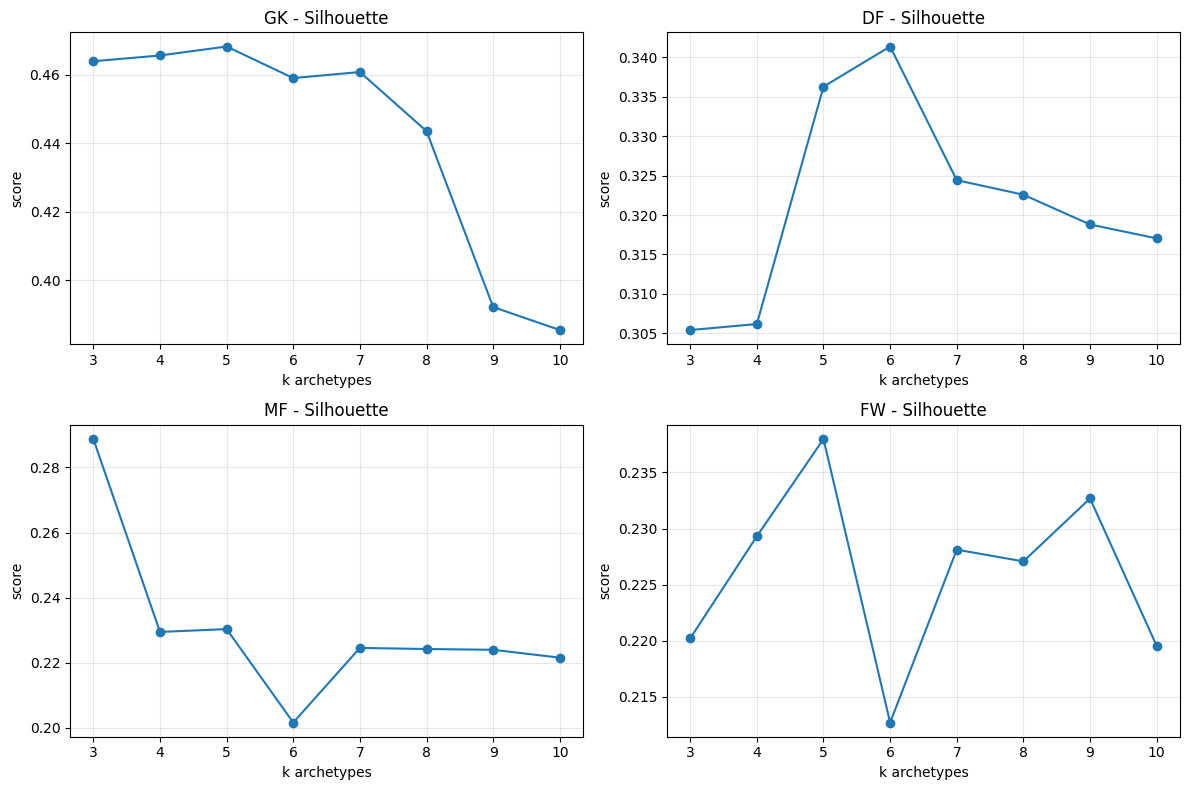

,table,best_k_by_silhouette,final_k_archetypes,note
0,DF,6,6,
1,FW,5,5,
2,GK,5,5,
3,MF,3,8,"Silhouette may favor ~4, but football knowledg..."


Final archetype count by table: {'GK': 5, 'DF': 6, 'MF': 8, 'FW': 5}
Models updated with final archetype counts.


In [120]:
# Evaluate KMeans quality across candidate cluster counts using silhouette only
def evaluate_archetype_k(X, k_min=3, k_max=10):
    rows = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=490, n_init=20)
        labels = km.fit_predict(X)
        rows.append({
            'k': k,
            'silhouette': silhouette_score(X, labels),
        })
    return pd.DataFrame(rows)

archetype_metrics_by_table = {}
for table_name, model in models.items():
    archetype_metrics_by_table[table_name] = evaluate_archetype_k(model['pca_scores'], k_min=3, k_max=10)

tables_order = ['GK', 'DF', 'MF', 'FW']

# Plot: silhouette only
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for i, table_name in enumerate(tables_order):
    mdf = archetype_metrics_by_table[table_name]
    axes[i].plot(mdf['k'], mdf['silhouette'], marker='o')
    axes[i].set_title(f'{table_name} - Silhouette')
    axes[i].set_xlabel('k archetypes')
    axes[i].set_ylabel('score')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Final archetype counts requested
N_ARCHETYPES_BY_TABLE = {
    'GK': 5,
    'DF': 6,
    'MF': 8,
    'FW': 5,
}

choice_rows = []
for table_name, mdf in archetype_metrics_by_table.items():
    k_best_sil = int(mdf.loc[mdf['silhouette'].idxmax(), 'k'])
    note = ''
    if table_name == 'MF':
        note = 'Silhouette may favor ~4, but football knowledge suggests more MF archetype diversity; use 8.'
    choice_rows.append({
        'table': table_name,
        'best_k_by_silhouette': k_best_sil,
        'final_k_archetypes': N_ARCHETYPES_BY_TABLE[table_name],
        'note': note
    })

archetype_choice_df = pd.DataFrame(choice_rows).sort_values('table').reset_index(drop=True)
display(archetype_choice_df)
print('Final archetype count by table:', N_ARCHETYPES_BY_TABLE)

# Update archetype labels in models
for table_name, model in models.items():
    k_final = N_ARCHETYPES_BY_TABLE.get(table_name, 5)
    km = KMeans(n_clusters=k_final, random_state=490, n_init=20)
    labels = km.fit_predict(model['pca_scores'])
    model['kmeans'] = km
    model['data']['archetype'] = labels

print('Models updated with final archetype counts.')

## Step 2.3 Result Summary

The silhouette table above shows the statistical best `k` for each table and the final selected `k`.
For MF, the final `k=8` is intentionally higher than the silhouette peak to reflect football role diversity.

## Step 2.4: Decision Summary from Plots

Based on the plots:
- PCA uses table-specific counts from `PCA_COMPONENTS_BY_TABLE`
- KNN `k` uses elbow-based values per group
- archetype count uses silhouette plus practical football constraints (MF intentionally set higher)

This table makes the final choices explicit.

In [121]:
decision_rows = []
for table_name, model in models.items():
    pca_used = PCA_COMPONENTS_BY_TABLE.get(table_name, model['pca_scores'].shape[1])
    explained_used = float(model['pca'].explained_variance_ratio_.sum())
    decision_rows.append({
        'table': table_name,
        'pca_components_used': pca_used,
        'variance_captured_by_used_pcs': round(explained_used, 3),
        'elbow_k_for_knn': recommended_k_by_table.get(table_name, np.nan),
        'archetype_k_final': N_ARCHETYPES_BY_TABLE.get(table_name, np.nan),
    })

decision_summary = pd.DataFrame(decision_rows).sort_values('table').reset_index(drop=True)
display(decision_summary)

print('Interpretation: PCA, KNN, and archetype counts are all selected using plots plus practical football logic.')

,table,pca_components_used,variance_captured_by_used_pcs,elbow_k_for_knn,archetype_k_final
0,DF,10,0.563,8,6
1,FW,11,0.514,8,5
2,GK,10,0.774,8,5
3,MF,12,0.541,8,8


Interpretation: PCA, KNN, and archetype counts are all selected using plots plus practical football logic.


## Step 2.5: Archetype Naming

We build readable archetype names from cluster feature profiles.
The name is based on dominant feature themes, so each archetype has both:
- numeric archetype id
- user-friendly archetype name

Code logic in this section:
- map feature names to football themes (for example: finishing, defending, progression)
- score themes by cluster profile values
- pick top themes to create an interpretable name
- write names back to each player row for export and search results

In [199]:
THEME_KEYWORDS = {
    'Shot Stopping': ['save', 'psxg', 'sota', 'ga90', 'ga_goals'],
    'Distribution': ['pass', 'cmp', 'launch', 'thr_', 'avglen'],
    'Aerial Control': ['cross', 'high', 'aerial', 'stp_'],
    'Finishing': ['gls', 'goal', 'shot', 'xg', 'npxg', 'sot'],
    'Chance Creation': ['ast', 'assist', 'xa', 'key', 'sca', 'gca', 'kp', 'ppa', 'crspa'],
    'Dribbling': ['dribble', 'take', 'touch_att_pen'],
    'Ball Carrying': ['carry', 'carries', 'cpa_', 'prgc_carries'],
    'Progression': ['progressive', 'prg', 'final_third', 'into_final_third', 'into_pen_area'],
    'Defending': ['tkl', 'tackle', 'int', 'block', 'clearance', 'sh_blocks', 'pass_blocks'],
    'Duel Strength': ['duel', 'challenge', 'won_aerial', 'lost_aerial', 'aerial_win'],
    'Possession Control': ['touch', 'dis_', 'mis_', 'recov', 'receiving'],
}


def build_theme_index(feature_cols):
    theme_to_cols = {theme: [] for theme in THEME_KEYWORDS}
    for col in feature_cols:
        col_l = str(col).lower()
        for theme, keywords in THEME_KEYWORDS.items():
            if any(keyword in col_l for keyword in keywords):
                theme_to_cols[theme].append(col)

    # Keep only themes that matched at least one feature column.
    return {theme: cols for theme, cols in theme_to_cols.items() if cols}


def score_themes_for_cluster(profile, theme_to_cols):
    theme_scores = {}
    for theme, cols in theme_to_cols.items():
        # Use only top positive feature values per theme so large theme groups do not dominate.
        top_vals = profile[cols].sort_values(ascending=False).head(min(3, len(cols)))
        if len(top_vals) > 0:
            theme_scores[theme] = float(top_vals.mean())
    return theme_scores


def pick_top_themes(theme_scores):
    if not theme_scores:
        return ['Balanced Play']

    ranked = sorted(theme_scores.items(), key=lambda x: x[1], reverse=True)

    # Prefer positive-style themes first.
    positive = [theme for theme, score in ranked if score > 0]
    if not positive:
        positive = [theme for theme, _ in sorted(theme_scores.items(), key=lambda x: abs(x[1]), reverse=True)]

    # If distribution is only slightly stronger, promote the next theme for better interpretability.
    if len(positive) >= 2 and positive[0] == 'Distribution':
        first_score = theme_scores.get(positive[0], 0)
        second_score = theme_scores.get(positive[1], 0)
        if second_score >= 0.8 * first_score:
            positive[0], positive[1] = positive[1], positive[0]

    return positive


def build_archetype_name(table_name, theme_list):
    role_name = {
        'GK': 'Goalkeeper',
        'DF': 'Defender',
        'MF': 'Midfielder',
        'FW': 'Forward',
    }.get(table_name, 'Player')

    if len(theme_list) >= 2:
        return f"{role_name}: {theme_list[0]} + {theme_list[1]}"
    if len(theme_list) == 1:
        return f"{role_name}: {theme_list[0]}"
    return f"{role_name}: Balanced Play"


archetype_name_rows = []

for table_name, model in models.items():
    df_model = model['data']
    feature_cols = model['feature_cols']
    cluster_means = df_model.groupby('archetype')[feature_cols].mean()

    theme_to_cols = build_theme_index(feature_cols)
    name_map = {}

    for cluster_id in cluster_means.index:
        profile = cluster_means.loc[cluster_id]
        top_high = profile.sort_values(ascending=False).head(3).index.tolist()
        top_low = profile.sort_values(ascending=True).head(2).index.tolist()

        theme_scores = score_themes_for_cluster(profile, theme_to_cols)
        top_themes = pick_top_themes(theme_scores)
        archetype_name = build_archetype_name(table_name, top_themes)
        name_map[int(cluster_id)] = archetype_name

        description = (
            f"Themes: {', '.join(top_themes[:3])} | "
            f"High: {', '.join(top_high)} | "
            f"Lower: {', '.join(top_low)}"
        )

        archetype_name_rows.append({
            'table': table_name,
            'archetype': int(cluster_id),
            'archetype_name': archetype_name,
            'profile_summary': description
        })

    model['archetype_name_map'] = name_map
    model['data']['archetype_name'] = model['data']['archetype'].map(name_map)

archetype_names_df = pd.DataFrame(archetype_name_rows).sort_values(['table', 'archetype']).reset_index(drop=True)
display(archetype_names_df)

,table,archetype,archetype_name,profile_summary
0,DF,0,Defender: Possession Control + Distribution,"Themes: Possession Control, Distribution, Prog..."
1,DF,1,Defender: Ball Carrying + Distribution,"Themes: Ball Carrying, Distribution, Chance Cr..."
2,DF,2,Defender: Distribution + Progression,"Themes: Distribution, Progression, Chance Crea..."
3,DF,3,Defender: Distribution,Themes: Distribution | High: season_end_year.1...
4,DF,4,Defender: Possession Control + Distribution,"Themes: Possession Control, Distribution, Ball..."
5,DF,5,Defender: Defending + Possession Control,"Themes: Defending, Possession Control, Duel St..."
6,FW,0,Forward: Aerial Control + Possession Control,"Themes: Aerial Control, Possession Control, Pr..."
7,FW,1,Forward: Distribution + Ball Carrying,"Themes: Distribution, Ball Carrying, Progressi..."
8,FW,2,Forward: Possession Control + Ball Carrying,"Themes: Possession Control, Ball Carrying, Pro..."
9,FW,3,Forward: Aerial Control + Distribution,"Themes: Aerial Control, Distribution, Duel Str..."


## Step 3: Build Helper Functions

This part creates two helper functions:
- get top-K similar players for one target
- export top-K neighbors for all players in one table

Logic:
- similarity is computed in PCA space with cosine distance
- each returned row includes player metadata, similarity score, archetype id/name, and PCA columns
- the export helper loops over all players and stacks one long result table

In [188]:
def get_top_k_similar_players(model, target_player, k=None, season=None):
    data = model['data']
    pca_scores = model['pca_scores']
    knn = model['knn']

    # Use elbow-based k when k is not provided.
    if k is None:
        k = recommended_k_by_table.get(model['table_name'], 10)

    # Find target row(s).
    mask = data['player'].str.lower() == str(target_player).lower()
    if season is not None and 'season_end_year' in data.columns:
        mask = mask & (data['season_end_year'] == season)

    target_rows = data[mask]
    if target_rows.empty:
        raise ValueError(f"Player '{target_player}' not found in {model['table_name']} table.")

    target_index = target_rows.index[0]
    target_pos = data.index.get_loc(target_index)

    distances, indices = knn.kneighbors(
        pca_scores[target_pos:target_pos + 1],
        n_neighbors=min(len(data), k + 1)
    )

    # Keep all PCA projection columns used in the model.
    pc_cols = sorted([c for c in data.columns if c.startswith('pc')], key=lambda s: int(s[2:]))

    output_rows = []
    target_row = data.loc[target_index]

    for dist, idx_pos in zip(distances[0], indices[0]):
        candidate = data.iloc[idx_pos]

        # Skip target player itself.
        if candidate.name == target_index:
            continue

        row = {
            'target_player': target_row['player'],
            'target_season': target_row.get('season_end_year', np.nan),
            'target_comp': target_row.get('comp', np.nan),
            'similarity_score': round(1 - float(dist), 4),     
            'archetype': int(candidate['archetype']),
            'archetype_name': candidate.get('archetype_name', ''),       
            'candidate_player': candidate['player'],
            'candidate_season': candidate.get('season_end_year', np.nan),
            'candidate_squad': candidate.get('squad', np.nan),
            'candidate_comp': candidate.get('comp', np.nan),
            'target_archetype': int(target_row['archetype']),
            'target_archetype_name': target_row.get('archetype_name', ''),
        }
        for pc in pc_cols:
            row[pc] = candidate.get(pc, np.nan)

        output_rows.append(row)

        if len(output_rows) >= k:
            break

    return pd.DataFrame(output_rows)


def export_top_k_for_all_players(model, k=None):
    data = model['data']
    result_rows = []

    if k is None:
        k = recommended_k_by_table.get(model['table_name'], 10)

    for i in range(len(data)):
        target_row = data.iloc[i]
        target_name = target_row['player']
        target_season = target_row.get('season_end_year', np.nan)

        top_k_df = get_top_k_similar_players(
            model=model,
            target_player=target_name,
            k=k,
            season=target_season
        )

        top_k_df['table'] = model['table_name']
        result_rows.append(top_k_df)

    return pd.concat(result_rows, ignore_index=True)

## Step 4: Export Main Results

Now we export the main result files:
- top-`k` neighbors for each table (using elbow-based `k`)
- archetype number and archetype name with PCA projections
- one combined file for all tables

Why we export all used PCA components:
- each table uses its own number of components in modeling from `PCA_COMPONENTS_BY_TABLE`.
- exporting all `pc` columns keeps full style-space information in final outputs.
- this makes downstream analysis more complete.

Export logic:
- save per-table files first
- then concatenate into all-table files
- also save simple quality checks (same-archetype share and recommended `k`)

In [200]:
OUTPUT_DIR = Path('outputs') / 'similarity_engine'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_neighbors = []
all_archetypes = []

for table_name, model in models.items():
    k_table = recommended_k_by_table.get(table_name, 10)
    print(f'Processing {table_name} with k={k_table}...')

    # Export neighbors for this position group.
    neighbors_df = export_top_k_for_all_players(model, k=None)
    neighbors_df.to_csv(OUTPUT_DIR / f"{table_name.lower()}_top_neighbors.csv", index=False)
    all_neighbors.append(neighbors_df)

    # Export archetypes (number + name) and all PCA components used by this table model.
    pc_cols = sorted([c for c in model['data'].columns if c.startswith('pc')], key=lambda s: int(s[2:]))
    archetype_cols = ['player', 'season_end_year', 'squad', 'comp', 'archetype', 'archetype_name'] + pc_cols
    keep_cols = [c for c in archetype_cols if c in model['data'].columns]
    archetypes_df = model['data'][keep_cols].copy()
    archetypes_df['table'] = table_name
    archetypes_df.to_csv(OUTPUT_DIR / f"{table_name.lower()}_archetypes_and_projections.csv", index=False)
    all_archetypes.append(archetypes_df)

neighbors_all_tables = pd.concat(all_neighbors, ignore_index=True)
neighbors_all_tables.to_csv(OUTPUT_DIR / 'all_tables_top_neighbors.csv', index=False)

archetypes_all_tables = pd.concat(all_archetypes, ignore_index=True)
archetypes_all_tables.to_csv(OUTPUT_DIR / 'all_tables_archetypes_and_projections.csv', index=False)

# Simple consistency metric: how often neighbor archetype equals target archetype.
if 'target_archetype' in neighbors_all_tables.columns and 'archetype' in neighbors_all_tables.columns:
    consistency = (
        neighbors_all_tables
        .assign(is_same_archetype=lambda d: d['target_archetype'] == d['archetype'])
        .groupby('table', as_index=False)['is_same_archetype']
        .mean()
        .rename(columns={'is_same_archetype': 'same_archetype_neighbor_share'})
    )
    consistency.to_csv(OUTPUT_DIR / 'retrieval_consistency_by_table.csv', index=False)
    display(consistency)

pd.DataFrame({
    'table': list(recommended_k_by_table.keys()),
    'elbow_k': list(recommended_k_by_table.values())
}).to_csv(OUTPUT_DIR / 'recommended_k_by_table.csv', index=False)

print('Files exported to:', OUTPUT_DIR)

Processing GK with k=8...
Processing DF with k=8...
Processing MF with k=8...
Processing FW with k=8...


,table,same_archetype_neighbor_share
0,DF,0.965145
1,FW,0.893221
2,GK,0.949770
3,MF,0.878981


Files exported to: outputs\similarity_engine


## Step 5: Cross-League Check

This final check measures how often similar players come from different leagues.
It helps show that the model can find cross-league stylistic matches.

Logic:
- compare target league (`target_comp`) and candidate league (`candidate_comp`)
- compute the share of cross-league neighbors per table
- higher values mean the model finds style matches beyond one domestic league

In [125]:
# Cross-league match rate: how often similar players come from a different league.
cross_league_by_table = (
    neighbors_all_tables
    .assign(is_cross_league=lambda d: d['target_comp'].astype(str) != d['candidate_comp'].astype(str))
    .groupby('table', as_index=False)['is_cross_league']
    .mean()
    .rename(columns={'is_cross_league': 'cross_league_neighbor_share'})
)

cross_league_by_table.to_csv(OUTPUT_DIR / 'cross_league_match_rate_by_table.csv', index=False)
display(cross_league_by_table)

,table,cross_league_neighbor_share
0,DF,0.752403
1,FW,0.771538
2,GK,0.760188
3,MF,0.771302


## Step 6: Search Player by Name, Season, and Top-K

This helper does everything in one function:
- search by player name (partial text is allowed)
- optional season filter
- choose how many lookalikes to return (`k`)
- return both name matches and lookalike list
- return a clear message when no player is found

Logic:
- first find candidate rows that match the player text
- optionally keep only one season
- pick one target row and run lookalike retrieval
- return both match table and lookalike table for easy inspection

In [126]:
def search_player_lookalikes(models, table='MF', player_name='', season=None, k=None):
    """
    One helper function that:
    1) searches players by name in one table
    2) optionally filters by season
    3) returns top-k lookalikes for the chosen player-season
    """
    data = models[table]['data']

    # Use elbow-based k when k is not provided.
    if k is None:
        k = recommended_k_by_table.get(table, 10)

    # Step 1: name search (partial match, case-insensitive).
    name_mask = data['player'].str.contains(str(player_name), case=False, na=False)
    matches = data.loc[name_mask, ['player', 'season_end_year', 'squad', 'comp']].copy()

    # Step 2: optional season filter.
    if season is not None:
        matches = matches[matches['season_end_year'] == season].copy()

    matches = (
        matches
        .drop_duplicates()
        .sort_values(['player', 'season_end_year'])
        .reset_index(drop=True)
    )

    # If no player found, return a clear response.
    if matches.empty:
        message = f"No player found for name='{player_name}' in table='{table}'"
        if season is not None:
            message += f" and season={season}"
        print(message)
        return {
            'found': False,
            'message': message,
            'matches': matches,
            'lookalikes': None
        }

    # Choose first matched row after filters.
    chosen = matches.iloc[0]

    lookalikes = get_top_k_similar_players(
        model=models[table],
        target_player=chosen['player'],
        k=k,
        season=chosen['season_end_year']
    )

    message = (
        f"Using player='{chosen['player']}', season={chosen['season_end_year']}, "
        f"table='{table}', k={k}"
    )
    print(message)

    return {
        'found': True,
        'message': message,
        'matches': matches,
        'lookalikes': lookalikes
    }

In [253]:
# Example with season filter
result_2 = search_player_lookalikes(
    models=models,
    table='DF',
    player_name='Nuno Mendes',
    season=2025,
    k=10
)

display(result_2['matches'].head(20))
if result_2['lookalikes'] is not None:
    display(result_2['lookalikes'])

Using player='Nuno Mendes', season=2025, table='DF', k=10


,player,season_end_year,squad,comp
0,Nuno Mendes,2025,Paris S-G,Ligue 1


,target_player,target_season,target_comp,similarity_score,archetype,archetype_name,candidate_player,candidate_season,candidate_squad,candidate_comp,target_archetype,target_archetype_name,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10
0,Nuno Mendes,2025,Ligue 1,0.9689,2,Defender: Distribution + Progression,Jules Koundé,2025,Barcelona,La Liga,2,Defender: Distribution + Progression,0.814468,0.158524,6.217750,-0.090598,1.663325,-1.568732,-0.627103,-0.020835,0.642829,0.764732
1,Nuno Mendes,2025,Ligue 1,0.9646,2,Defender: Distribution + Progression,Alessandro Bastoni,2025,Inter,Serie A,2,Defender: Distribution + Progression,1.263269,-0.671154,6.097569,0.941037,1.491910,-1.297998,-1.227614,0.556152,0.018937,1.022586
2,Nuno Mendes,2025,Ligue 1,0.9621,2,Defender: Distribution + Progression,Achraf Hakimi,2025,Paris S-G,Ligue 1,2,Defender: Distribution + Progression,1.979905,0.892873,7.922363,-1.405454,1.620430,-1.154102,-0.286436,-0.416790,0.542840,1.113808
3,Nuno Mendes,2025,Ligue 1,0.9458,2,Defender: Distribution + Progression,Trent Alexander-Arnold,2025,Liverpool,Premier League,2,Defender: Distribution + Progression,1.804783,2.088305,6.424884,-0.041259,2.736456,-0.913354,-1.612196,1.445736,0.012625,1.734278
4,Nuno Mendes,2025,Ligue 1,0.9425,2,Defender: Distribution + Progression,Alejandro Balde,2025,Barcelona,La Liga,2,Defender: Distribution + Progression,-0.465407,0.322284,5.565915,-0.211504,1.385114,-1.940405,-0.776820,0.729719,0.058219,0.712136
5,Nuno Mendes,2025,Ligue 1,0.9345,2,Defender: Distribution + Progression,Sacha Boey,2025,Bayern Munich,Bundesliga,2,Defender: Distribution + Progression,-0.114659,0.122799,5.027303,1.206388,1.527959,-1.116491,0.149989,0.410004,-0.465851,0.730928
6,Nuno Mendes,2025,Ligue 1,0.9331,2,Defender: Distribution + Progression,Andrew Robertson,2025,Liverpool,Premier League,2,Defender: Distribution + Progression,0.060843,1.321209,5.840126,0.554306,1.569635,-2.038712,-0.740819,0.729683,0.488402,0.953448
7,Nuno Mendes,2025,Ligue 1,0.9302,2,Defender: Distribution + Progression,Alphonso Davies,2025,Bayern Munich,Bundesliga,2,Defender: Distribution + Progression,0.143010,0.239295,6.569440,-0.644861,1.401835,-2.215663,-0.263538,-0.373424,0.686443,0.379528
8,Nuno Mendes,2025,Ligue 1,0.9299,2,Defender: Distribution + Progression,Andrea Cambiaso,2025,Juventus,Serie A,2,Defender: Distribution + Progression,-0.206989,0.244689,4.304326,1.017045,1.624978,-0.724766,-0.627364,-0.087011,-0.293739,0.281463
9,Nuno Mendes,2025,Ligue 1,0.9286,2,Defender: Distribution + Progression,Michael Amir Murillo,2025,Marseille,Ligue 1,2,Defender: Distribution + Progression,-0.207179,-0.381787,4.639817,0.834959,1.964188,-0.760721,-0.039724,-0.082906,-0.021390,0.534469


## Conclusion

The goal here is to build a practical similarity engine for football players, based on playing style and not only on raw output numbers. The workflow starts from position-based model-ready data, because comparing players across different positions is usually misleading. This makes the analysis more fair and more useful.

The core pipeline has four parts. First, PCA reduces feature space to remove noise and overlap between correlated metrics. Second, cosine-based KNN finds lookalike players in style space. Third, K-means groups players into archetypes. Finally, the notebook exports reusable outputs for analysis and reporting.

Diagnostic plots support the model choices. Scree plots and elbow plots help define practical settings per position group. For archetypes, silhouette gives the statistical baseline, and football logic is used for final tuning (especially for midfield diversity).

The final outputs include top neighbors, similarity scores, archetype number and archetype name, PCA projections, cross-league match rate, and recommended `k` by table. These outputs show structure inside position groups, meaningful cross-league style matches, and consistent retrieval behavior.

Overall, the result is an interpretable and reproducible lookalike system that can be maintained and extended with new models later.